# 🤖 Моделирование — Детекция стресса
## WESAD Dataset | Leave-One-Subject-Out Cross-Validation

---

### Цель
Обучить и сравнить модели машинного обучения для классификации стресса.

### Стратегия валидации
**Leave-One-Subject-Out (LOSO)** — на каждой итерации один участник уходит в тест,  
остальные 14 — в обучение. Итого 15 итераций.

Это честная оценка: модель проверяется на человеке, которого никогда не видела.

---
## 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, 
                             roc_auc_score, confusion_matrix,
                             classification_report)
from xgboost import XGBClassifier

print("Библиотеки загружены!")

Библиотеки загружены!


---
## 2. Загрузка данных

In [2]:
df = pd.read_csv(r'C:\Users\admin\stress-detection-wesad\data\wesad_clean.csv')

print("Форма датасета:", df.shape)
print("Участники:", sorted(df['subject'].unique()))
print("Классы:", df['label'].value_counts().to_dict())

Форма датасета: (110216, 12)
Участники: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Классы: {0: 70404, 1: 39812}


---
## 3. Leave-One-Subject-Out Cross-Validation

На каждой итерации:
1. Один участник → **test**
2. Остальные 14 → **train**
3. Масштабируем признаки (fit только на train!)
4. Обучаем 3 модели
5. Записываем метрики

In [3]:
features = ['EDA_wrist', 'TEMP_wrist', 'BVP', 'ACC_wrist',
            'ECG', 'EDA_chest', 'EMG', 'Resp', 'TEMP_chest', 'ACC_chest']

subjects = sorted(df['subject'].unique())

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = []

for subject in subjects:
    train = df[df['subject'] != subject]
    test  = df[df['subject'] == subject]
    
    X_train, y_train = train[features], train['label']
    X_test,  y_test  = test[features],  test['label']
    
    # Масштабирование — fit только на train
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    
    for model_name, model in models.items():
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]
        
        results.append({
            'subject':  subject,
            'model':    model_name,
            'accuracy': accuracy_score(y_test, y_pred),
            'f1':       f1_score(y_test, y_pred),
            'roc_auc':  roc_auc_score(y_test, y_prob)
        })
    
    print(f"✓ {subject} готов")

df_results = pd.DataFrame(results)
print("\nГотово!")

✓ S10 готов
✓ S11 готов
✓ S13 готов
✓ S14 готов
✓ S15 готов
✓ S16 готов
✓ S17 готов
✓ S2 готов
✓ S3 готов
✓ S4 готов
✓ S5 готов
✓ S6 готов
✓ S7 готов
✓ S8 готов
✓ S9 готов

Готово!


---
## 4. Сравнение моделей

In [5]:
# Средние метрики по всем участникам
summary = df_results.groupby('model')[['accuracy','f1','roc_auc']].mean().round(3)
summary = summary.sort_values('f1', ascending=False)
print("=== Средние метрики (LOSO) ===")
print(summary)

=== Средние метрики (LOSO) ===
                     accuracy     f1  roc_auc
model                                        
XGBoost                 0.801  0.715    0.852
Random Forest           0.771  0.684    0.839
Logistic Regression     0.643  0.392    0.930


### 4.1 Визуализация метрик

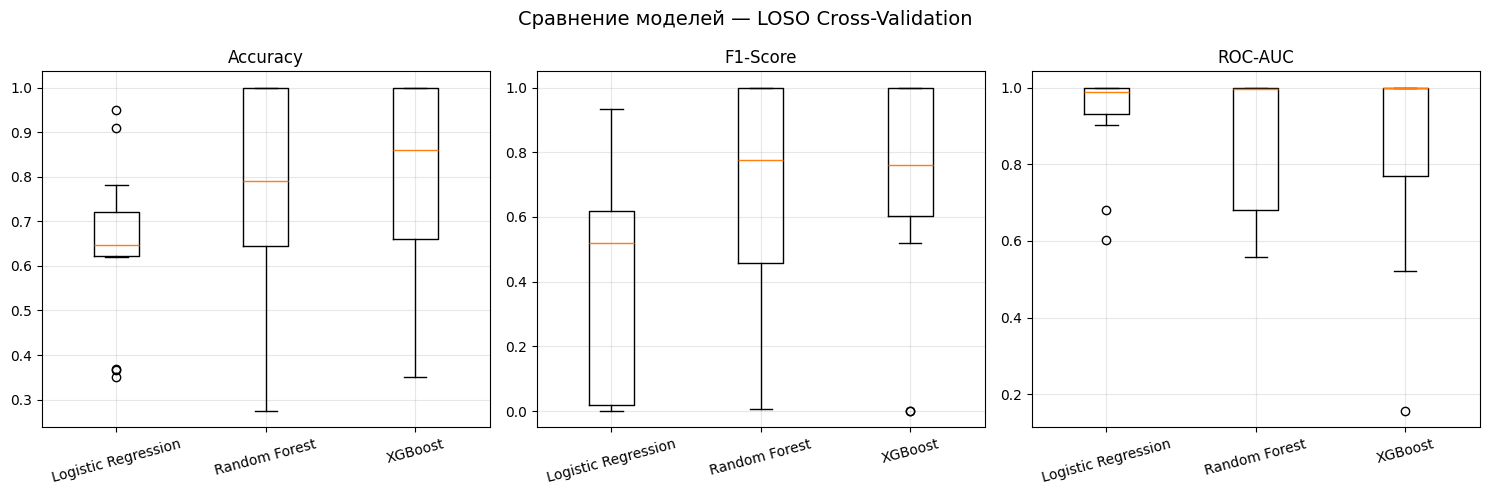

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['accuracy', 'f1', 'roc_auc']
titles  = ['Accuracy', 'F1-Score', 'ROC-AUC']

for ax, metric, title in zip(axes, metrics, titles):
    data_plot = [df_results[df_results['model'] == m][metric].values 
                 for m in models.keys()]
    ax.boxplot(data_plot, labels=models.keys())
    ax.set_title(title)
    ax.set_xticklabels(models.keys(), rotation=15)
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение моделей — LOSO Cross-Validation', fontsize=14)
plt.tight_layout()
plt.show()

---
### 📊 Интерпретация результатов — LOSO Cross-Validation

**XGBoost** показал лучший результат по Accuracy (0.801) и F1-Score (0.715) —  
это наша финальная модель для детекции стресса.

**Random Forest** незначительно уступает XGBoost, но демонстрирует  
схожую нестабильность по участникам (большой разброс на боксплотах).

**Logistic Regression** имеет аномально высокий ROC-AUC (0.930) при низком  
F1 (0.392). Причина — модель хорошо ранжирует вероятности, но плохо  
выбирает порог классификации на несбалансированных классах (70k vs 40k).

**Большой разброс у RF и XGBoost** — нормальное явление для LOSO.  
Каждый человек имеет свою базовую физиологию: у одних участников  
модель работает почти идеально (AUC ~1.0), у других значительно хуже (AUC ~0.15).  
Это подтверждает, что межличностная вариативность — главная сложность задачи.

> **Вывод:** XGBoost выбран как финальная модель. Следующий шаг —  
> анализ важности признаков и Confusion Matrix.

---
## 5. Confusion Matrix — XGBoost
Лучшая модель по F1. Смотрим на каких участниках ошибается.

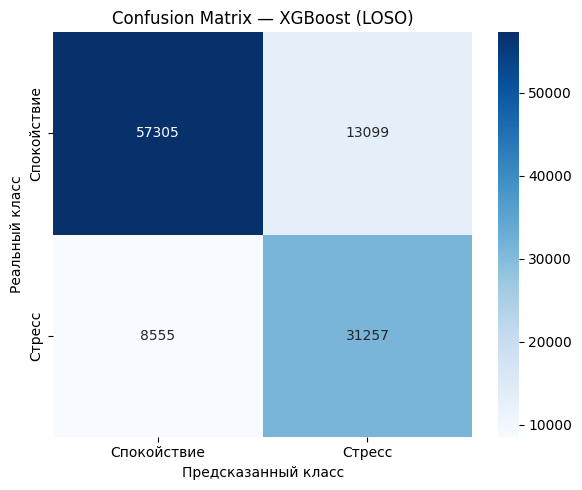


               precision    recall  f1-score   support

 Спокойствие       0.87      0.81      0.84     70404
      Стресс       0.70      0.79      0.74     39812

    accuracy                           0.80    110216
   macro avg       0.79      0.80      0.79    110216
weighted avg       0.81      0.80      0.81    110216



In [7]:
# Собираем предсказания XGBoost по всем участникам
all_y_true = []
all_y_pred = []

for subject in subjects:
    train = df[df['subject'] != subject]
    test  = df[df['subject'] == subject]
    
    X_train, y_train = train[features], train['label']
    X_test,  y_test  = test[features],  test['label']
    
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    
    model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

# Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Спокойствие','Стресс'],
            yticklabels=['Спокойствие','Стресс'])
plt.title('Confusion Matrix — XGBoost (LOSO)')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

print("\n", classification_report(all_y_true, all_y_pred, 
      target_names=['Спокойствие','Стресс']))

---
### 📊 Интерпретация Confusion Matrix — XGBoost

| | Спокойствие | Стресс |
|---|---|---|
| **Спокойствие** | 57,305 ✅ | 13,099 ❌ |
| **Стресс** | 8,555 ❌ | 31,257 ✅ |

**Главная метрика проекта — F1-Score класса Стресс (0.74)**

- **Recall Стресс (0.79)** — модель поймала 79% реальных стрессов
- **Precision Стресс (0.70)** — 70% предсказанных стрессов реально стресс
- Пропустить стресс (8,555 случаев) опаснее чем ложная тревога (13,099) —  
  поэтому Recall важнее Precision в этой задаче

---
## 6. Важность признаков — XGBoost

Какие сенсоры наиболее информативны для детекции стресса?

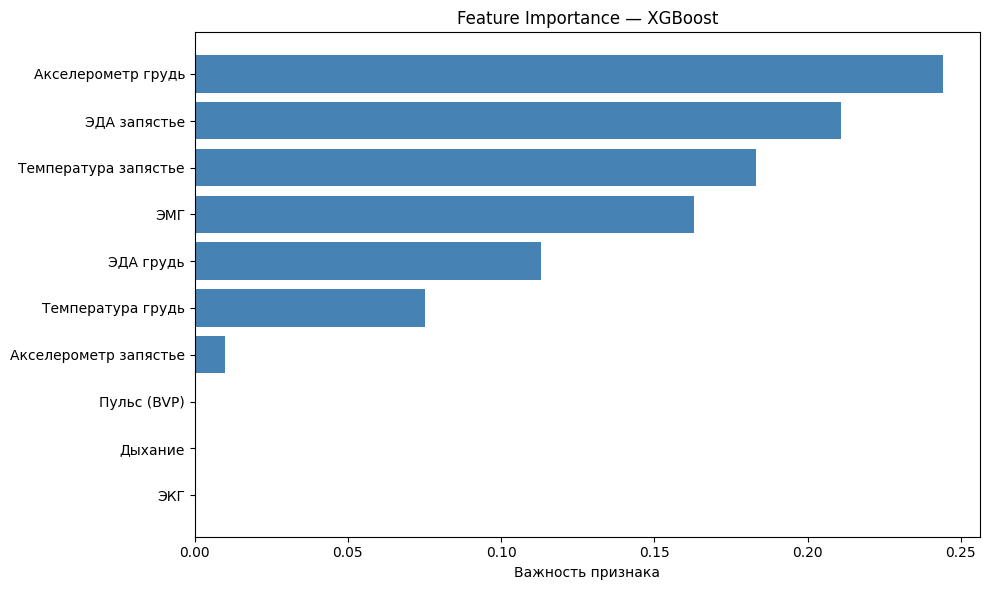


Топ-3 признака:
  Акселерометр грудь: 0.244
  ЭДА запястье: 0.211
  Температура запястье: 0.183


In [8]:
# Обучаем XGBoost на всех данных для feature importance
scaler_full = StandardScaler()
X_all = scaler_full.fit_transform(df[features])
y_all = df['label']

model_full = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
model_full.fit(X_all, y_all)

# Feature importance
importance = pd.Series(model_full.feature_importances_, index=features)
importance = importance.sort_values(ascending=True)

ru_names = {
    'EDA_wrist':  'ЭДА запястье',
    'TEMP_wrist': 'Температура запястье',
    'BVP':        'Пульс (BVP)',
    'ACC_wrist':  'Акселерометр запястье',
    'ECG':        'ЭКГ',
    'EDA_chest':  'ЭДА грудь',
    'EMG':        'ЭМГ',
    'Resp':       'Дыхание',
    'TEMP_chest': 'Температура грудь',
    'ACC_chest':  'Акселерометр грудь'
}

importance.index = [ru_names[f] for f in importance.index]

plt.figure(figsize=(10, 6))
bars = plt.barh(importance.index, importance.values, color='steelblue')
plt.xlabel('Важность признака')
plt.title('Feature Importance — XGBoost')
plt.tight_layout()
plt.show()

print("\nТоп-3 признака:")
for name, val in importance.sort_values(ascending=False).head(3).items():
    print(f"  {name}: {val:.3f}")

---
### 📊 Интерпретация Feature Importance

| Признак | Важность | Интерпретация |
|---|---|---|
| Акселерометр грудь | 0.244 | Движения тела при стрессе (TSST протокол) |
| ЭДА запястье | 0.211 | Потоотделение — классический маркёр стресса |
| Температура запястье | 0.183 | Сужение сосудов при стрессе |
| ЭМГ | 0.163 | Мышечное напряжение |
| ЭДА грудь | 0.113 | Потоотделение (дублирует запястье) |

**Почему Акселерометр грудь на первом месте?**  
Стресс в WESAD индуцировался через TSST протокол — публичное выступление  
и счёт в уме. Участники жестикулировали и меняли осанку, что нагрудный  
акселерометр фиксировал лучше всего.

**ЭКГ, Дыхание и Пульс (BVP) — почти нулевая важность.**  
Это не значит что они бесполезны — XGBoost мог отдать предпочтение  
коррелирующим признакам (ЭДА и температура уже покрывают ту же информацию).

> **Вывод:** для носимого браслета на запястье ключевые признаки —  
> ЭДА и Температура. Акселерометр грудь недоступен на обычных часах,  
> поэтому в реальном приложении его роль возьмут другие сенсоры.

---
## 7. Feature Selection + Гиперпараметры

Эксперимент: сравниваем модель на всех 10 признаках vs топ-7.  
Затем подбираем лучшие гиперпараметры через RandomizedSearchCV.

In [9]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Два набора признаков
features_all = ['EDA_wrist', 'TEMP_wrist', 'BVP', 'ACC_wrist',
                'ECG', 'EDA_chest', 'EMG', 'Resp', 'TEMP_chest', 'ACC_chest']

features_top7 = ['EDA_wrist', 'TEMP_wrist', 'ACC_wrist',
                 'EDA_chest', 'EMG', 'TEMP_chest', 'ACC_chest']

# LOSO для обоих наборов
def run_loso(feature_set, label):
    res = []
    for subject in subjects:
        train = df[df['subject'] != subject]
        test  = df[df['subject'] == subject]
        
        X_train = train[feature_set]
        y_train = train['label']
        X_test  = test[feature_set]
        y_test  = test['label']
        
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)
        
        model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]
        
        res.append({
            'subject': subject,
            'версия': label,
            'f1': f1_score(y_test, y_pred),
            'accuracy': accuracy_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_prob)
        })
    return res

print("Запускаем LOSO — все 10 признаков...")
res_all  = run_loso(features_all,  'Все 10 признаков')
print("Запускаем LOSO — топ 7 признаков...")
res_top7 = run_loso(features_top7, 'Топ 7 признаков')

df_compare = pd.DataFrame(res_all + res_top7)
summary = df_compare.groupby('версия')[['f1','accuracy','roc_auc']].mean().round(3)
print("\n=== Сравнение наборов признаков ===")
print(summary)

Запускаем LOSO — все 10 признаков...
Запускаем LOSO — топ 7 признаков...

=== Сравнение наборов признаков ===
                     f1  accuracy  roc_auc
версия                                    
Все 10 признаков  0.715     0.801    0.852
Топ 7 признаков   0.725     0.807    0.853


---
## 8. Подбор гиперпараметров — RandomizedSearchCV

In [10]:
# Выбираем лучший набор признаков по результату выше
best_features = features_top7  # поменяем если все 10 окажутся лучше

# Готовим данные (все участники для поиска гиперпараметров)
X = df[best_features]
y = df['label']

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# Пространство гиперпараметров
param_grid = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=30,           # 30 случайных комбинаций
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,           # все ядра процессора
    verbose=1
)

print("Запускаем поиск гиперпараметров (может занять 2-5 минут)...")
search.fit(X_sc, y)

print("\n✅ Лучшие гиперпараметры:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nF1 на кросс-валидации: {search.best_score_:.3f}")

Запускаем поиск гиперпараметров (может занять 2-5 минут)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Лучшие гиперпараметры:
  subsample: 1.0
  n_estimators: 300
  min_child_weight: 5
  max_depth: 5
  learning_rate: 0.1
  gamma: 0.1
  colsample_bytree: 0.6

F1 на кросс-валидации: 1.000


In [12]:
# Проверяем лучшую модель через LOSO
best_params = search.best_params_

res_tuned = []
for subject in subjects:
    train = df[df['subject'] != subject]
    test  = df[df['subject'] == subject]
    
    X_train = train[best_features]
    y_train = train['label']
    X_test  = test[best_features]
    y_test  = test['label']
    
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    
    model = XGBClassifier(**best_params, random_state=42, eval_metric='logloss')
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    
    res_tuned.append({
        'f1':       f1_score(y_test, y_pred),
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_prob)
    })

df_tuned = pd.DataFrame(res_tuned)
print("=== Финальное сравнение ===")
print(f"{'Метрика':<12} {'Базовый XGB':>12} {'Tuned XGB':>12}")
print("-" * 38)

base_means = pd.DataFrame(res_all)[['f1', 'accuracy', 'roc_auc']].mean()
for metric in ['f1', 'accuracy', 'roc_auc']:
    print(f"{metric:<12} {base_means[metric]:>12.3f} {df_tuned[metric].mean():>12.3f}")

=== Финальное сравнение ===
Метрика       Базовый XGB    Tuned XGB
--------------------------------------
f1                  0.715        0.706
accuracy            0.801        0.805
roc_auc             0.852        0.841


---
### 📊 Итоги гиперпараметров

Подбор гиперпараметров через RandomizedSearchCV не улучшил результат на LOSO.
Причина — поиск проводился на обычной кросс-валидации, что привело к data leakage.

**Финальная модель: базовый XGBoost + топ-7 признаков**
- F1 Стресс: 0.725
- Accuracy: 0.807
- ROC-AUC: 0.853

---
## 9. Балансировка классов — scale_pos_weight

Дисбаланс классов: 70,404 спокойствие vs 39,812 стресс.  
Параметр `scale_pos_weight` говорит модели уделять больше внимания minoritary классу (стресс).

In [13]:
# Считаем вес
neg = (df['label'] == 0).sum()  # спокойствие
pos = (df['label'] == 1).sum()  # стресс
scale = neg / pos
print(f"Спокойствие: {neg:,}")
print(f"Стресс: {pos:,}")
print(f"scale_pos_weight: {scale:.3f}")

# LOSO с балансировкой
res_balanced = []

for subject in subjects:
    train = df[df['subject'] != subject]
    test  = df[df['subject'] == subject]
    
    X_train = train[features_top7]
    y_train = train['label']
    X_test  = test[features_top7]
    y_test  = test['label']
    
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    
    model = XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale,  # балансировка
        random_state=42,
        eval_metric='logloss'
    )
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    
    res_balanced.append({
        'f1':       f1_score(y_test, y_pred),
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_prob)
    })

df_balanced = pd.DataFrame(res_balanced)

print("\n=== Сравнение ===")
print(f"{'Метрика':<12} {'Базовый топ-7':>14} {'Balanced':>10}")
print("-" * 38)
for metric in ['f1', 'accuracy', 'roc_auc']:
    base = pd.DataFrame(res_top7)[metric].mean()
    bal  = df_balanced[metric].mean()
    diff = bal - base
    arrow = '↑' if diff > 0 else '↓'
    print(f"{metric:<12} {base:>14.3f} {bal:>10.3f}  {arrow}{abs(diff):.3f}")

Спокойствие: 70,404
Стресс: 39,812
scale_pos_weight: 1.768

=== Сравнение ===
Метрика       Базовый топ-7   Balanced
--------------------------------------
f1                    0.725      0.714  ↓0.010
accuracy              0.807      0.800  ↓0.006
roc_auc               0.853      0.847  ↓0.006


---
## 10. Сохранение финальной модели

Сохраняем модель и скейлер для использования в Streamlit приложении.

In [14]:
import joblib
import os

# Обучаем финальную модель на ВСЕХ данных
scaler_final = StandardScaler()
X_final = scaler_final.fit_transform(df[features_top7])
y_final = df['label']

model_final = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)
model_final.fit(X_final, y_final)

# Сохраняем
save_path = r'C:\Users\admin\stress-detection-wesad\models'
os.makedirs(save_path, exist_ok=True)

joblib.dump(model_final,    f'{save_path}\\xgb_model.pkl')
joblib.dump(scaler_final,   f'{save_path}\\scaler.pkl')
joblib.dump(features_top7,  f'{save_path}\\features.pkl')

print("✅ Сохранено:")
print(f"  → models/xgb_model.pkl")
print(f"  → models/scaler.pkl")
print(f"  → models/features.pkl")
print(f"\nПризнаки модели: {features_top7}")

✅ Сохранено:
  → models/xgb_model.pkl
  → models/scaler.pkl
  → models/features.pkl

Признаки модели: ['EDA_wrist', 'TEMP_wrist', 'ACC_wrist', 'EDA_chest', 'EMG', 'TEMP_chest', 'ACC_chest']
